# Extended Data Figure 2 - Single cell GFP distributions
Tested in 293Ts, 20k cells/well at 96-well scale \ 
Sparsely labeled eGFP cells \ 
Infected at 6-well scale \
Reseed at 20k/well into antibiotic conditions \
Media change every other day \



Reps:
- 2026.06.03: 3 reps


In [4]:
import rushd as rd
import matplotlib
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from textwrap import wrap
from statannotations.Annotator import Annotator
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.stats import poisson
from matplotlib.patches import Patch

## Load Data

In [5]:
# Set paths to the experiment folder and where to find the data
base_path = rd.datadir/'data'/'attune'/'Mary'

Plates = {'2026.06.03_exp47': ['Plate1', 'Plate2', 'Plate3', 'Plate4']
}

exp_path = []
yaml_path = []

for i in Plates:
    for j in Plates[i]:
        exp_path.append(base_path/i/j/'export_singlets')
        yaml_path.append(base_path/i/j/'export_singlets'/'well_metadata.yaml')

output_path = rd.rootdir/'output'/'Figure_XX_single_cells'
cache_path = rd.rootdir/'output'/'Figure_XX_single_cells'/'data.gzip'

plates_dict = pd.DataFrame({
    'data_path' : [exp for exp in exp_path],
    'yaml_path' : [yaml for yaml in yaml_path]
})

display(plates_dict)

,data_path,yaml_path
0,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
1,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
2,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
3,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...


In [9]:
#Load data
data = pd.DataFrame()
if cache_path.is_file(): data = pd.read_parquet(cache_path)
else:
    channel_list = ['mGL-H','mGL-A', 'iRFP670-A','iRFP670-H', 'FSC-A', 'mRuby2-A', 'mRuby2-H','TagBFP-A', 'TagBFP-H']
    data = rd.flow.load_groups_with_metadata(plates_dict,columns=channel_list) #Could add in columns=channel_list here to get specific columns

    # Remove NaN values
    data.dropna(inplace=True)

    # Save data in the cache path for easier loading next time
    data.to_parquet(rd.outfile(cache_path))


In [10]:
data['conds'] = data['reporter'] +'.'+ data['Puro'] 
display(data)

,reporter,Puro,Puro#,Date,well,population,FSC-A,mGL-A,mGL-H,iRFP670-A,iRFP670-H,TagBFP-A,TagBFP-H,mRuby2-A,mRuby2-H,conds
0,pKG05002,10x,10.0,2026.06.03.x,A10,Single Cells,239937,114.0,89.0,20199.0,17256.0,51.0,84.0,90.0,186.0,pKG05002.10x
1,pKG05002,10x,10.0,2026.06.03.x,A10,Single Cells,420539,-78.0,80.0,17792.0,13077.0,-14.0,58.0,-66.0,70.0,pKG05002.10x
2,pKG05002,10x,10.0,2026.06.03.x,A10,Single Cells,360555,66680.0,48986.0,46504.0,37146.0,570.0,381.0,23058.0,17791.0,pKG05002.10x
3,pKG05002,10x,10.0,2026.06.03.x,A10,Single Cells,303230,67.0,50.0,10007.0,8310.0,255.0,141.0,167.0,204.0,pKG05002.10x
4,pKG05002,10x,10.0,2026.06.03.x,A10,Single Cells,288188,78.0,63.0,17562.0,14627.0,155.0,151.0,225.0,235.0,pKG05002.10x
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23010622,Untransfected,0x,0.0,2026.06.03.xxx,E9,Single Cells,368281,63.0,87.0,-17.0,58.0,39.0,147.0,25.0,107.0,Untransfected.0x
23010623,Untransfected,0x,0.0,2026.06.03.xxx,E9,Single Cells,442954,65.0,143.0,73.0,105.0,265.0,113.0,136.0,156.0,Untransfected.0x
23010624,Untransfected,0x,0.0,2026.06.03.xxx,E9,Single Cells,486336,76.0,85.0,91.0,80.0,275.0,141.0,107.0,90.0,Untransfected.0x
23010625,Untransfected,0x,0.0,2026.06.03.xxx,E9,Single Cells,390673,97.0,88.0,105.0,74.0,99.0,96.0,171.0,171.0,Untransfected.0x


**Plot untransfected**

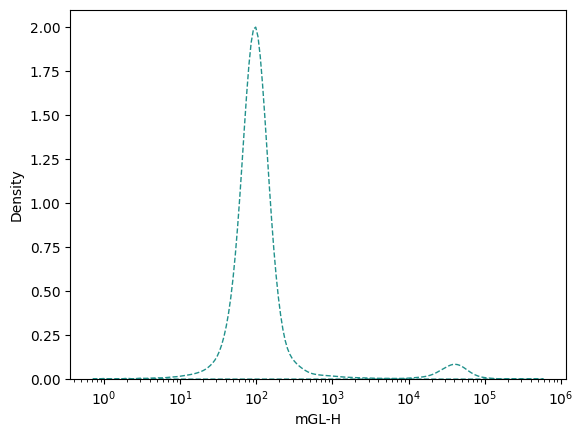

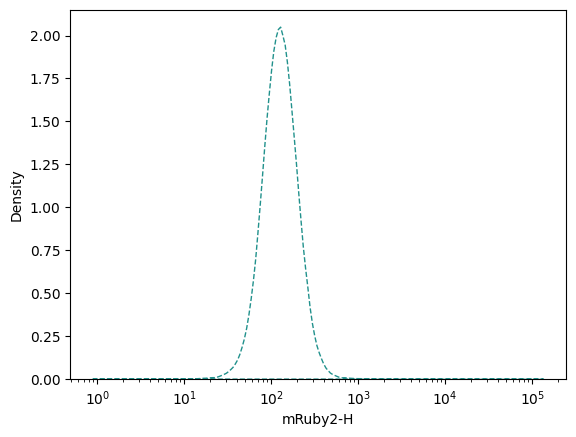

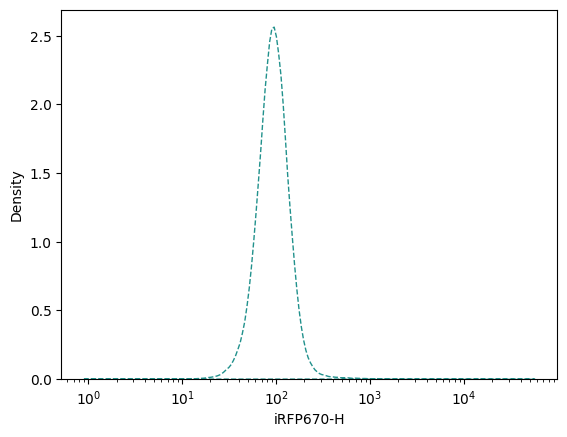

In [11]:
parameters = np.array(['mGL-H', 'mRuby2-H', 'iRFP670-H'])
for param in parameters:
    untransfected = data[(data['reporter'] == 'Untransfected') & (data[param] > 0) ]
    g = plt.figure()
    sns.kdeplot(untransfected, x=param,hue='reporter',log_scale=True,legend=False,fill=True,common_norm=False,palette='viridis', alpha = 0, linestyle = '--')

In [14]:
iRFP670_H_thresh = 2.5e2
eGFP_gate = 3000

In [13]:
data = data[(data['reporter'] != 'pKG04437.Controls') & (data['reporter'] != 'pKG05003.Controls')]

## Extended Data Figure 2C

**Extedended Data Figure 2C**

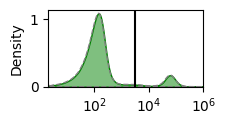

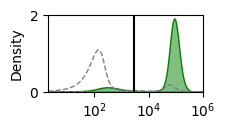

In [20]:
reporters = ['pKG05002']
parameters = pd.array(['mGL-A', 'TagBFP-A'])
plottitle = np.array(['0x_5002.svg', '40x_5002.svg'])
# plottitle = np.array(['0x_5002.svg', '2_5x_5002.svg', '5x_5002.svg', '10x_5002.svg', '20x_5002.svg', '40x_5002.svg'])
puro = np.array(['0x', '40x'])

xsize = 2; ysize = 1; figsize = (xsize, ysize)
untransfected = data[data['reporter'] == 'Untransfected']
for j in range(2):
    plt.figure(figsize=figsize)
    underlay = data[(data['reporter'] == 'pKG05002') & (data['Puro'] == '0x') & (data['mGL-A'] > 0)]
    data_now = data[(data['reporter'] == reporters[0]) & (data['Puro']==puro[j]) & (data['mGL-A'] > 0)]
    g = sns.kdeplot(data=data_now, x=parameters[0],y=None,hue='conds', legend=False,
                    log_scale=True,fill=True, alpha = 0.5,common_norm=True,palette=['green'])
    g = sns.kdeplot(data=underlay, x=parameters[0],y=None,hue='conds', legend=False,
                    log_scale=True,fill=True, alpha = 0,common_norm=True,palette=['grey'], linestyle = '--')
    plt.gca().set_xlabel("")
    g.set_xlim(xmin=2, xmax=10**6)
    g = plt.axvline(eGFP_gate, color = 'k')
    # g.spines['top'].set_visible(False)
    # g.spines['right'].set_visible(False)
    g = g.get_figure()
    g.savefig(rd.outfile(output_path/plottitle[j]),bbox_inches='tight')